# 02 — The Haslam side, and the prior problem

Stage 2 builds the three things `bayesian_skymap` needs on the miscalibrated leg:
the Haslam map (`sky_gain`), the gain and spectral-index region operators
(`operator`, `operator_spect`), and the prior covariance `covA`.

The notebook is named for Berkhuijsen (1972) because that survey is what **should**
supply the prior — it is the one basis independent of Haslam itself. It is not in hand,
and this notebook is where that matters, because the obvious substitute is worse than it
looks: **GSM2008's 408 MHz component *is* the Haslam map**. Section 3 demonstrates that
rather than asserting it.

Run stage 2 first:

```
python run_pipeline.py --stage 2
```

In [1]:
%matplotlib inline
import os
os.environ["TQDM_DISABLE"] = "1"

import sys
import warnings
from pathlib import Path

import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "src"))

warnings.filterwarnings("ignore", category=UserWarning)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "figure.facecolor": "white"})

from moonrunes.config import load_config
from moonrunes import stage2_haslam_prep as stage2

config = load_config(REPO / "configs" / "run_config.yaml")
products = stage2.load_stage2(config)
manifest = products.manifest

NSIDE = products.nside
NPIX = hp.nside2npix(NSIDE)

print("products", products.products_path)
print("written ", manifest["written_utc"])
print()
print(f"frame {products.frame}, nside {NSIDE} ({NPIX} pixels)")
print(f"Haslam  {manifest['haslam']['source']}")
print(f"        native nside {manifest['haslam']['native_nside']}, "
      f"CMB monopole {manifest['haslam']['cmb_monopole_removed_k']:.4f} K removed")
print(f"regions {manifest['regions']['n_gain_regions']} gain / "
      f"{manifest['regions']['n_beta_regions']} beta, "
      f"{manifest['regions']['geometry']}")
print(f"prior   {manifest['prior']['source']}  ->  "
      f"Haslam-derived: {manifest['prior_is_haslam_derived']}")

products /Users/user/Documents/Codes/project3/moonrunes/outputs/stage2/haslam_prep_tris_haslam_v0.npz
written  2026-09-03T21:08:20+00:00

frame galactic, nside 128 (196608 pixels)
Haslam  pygdsm astropy cache (Remazeilles 2015 dsds)
        native nside 512, CMB monopole 2.7157 K removed
regions 12 gain / 6 beta, theta_bands
prior   gsm2008  ->  Haslam-derived: True


---
## 1. The Haslam map

The destriped, desourced reprocessing (Remazeilles et al. 2015), degraded from its native
nside 512 to `bayesian_skymap`'s fixed nside 128 grid, in galactic coordinates.

The CMB monopole is removed first. That is not cosmetic: `bayesian_skymap` models this map
as `gain × s × (freq/ref)^beta`, a pure power law with **no monopole term**, so leaving
2.7 K in it makes the forward model wrong everywhere. The Rayleigh–Jeans value at 408 MHz
is used rather than the thermodynamic 2.7255 K, because stage 1 established that this
pipeline works in RJ.

                             min    median       max
sky_gain [K]                8.89     22.29    4131.1

strictly positive everywhere: True
  (covA is inverted per pixel by the sampler, so a zero or a negative here
   would blow up the amplitude solve rather than fail loudly)


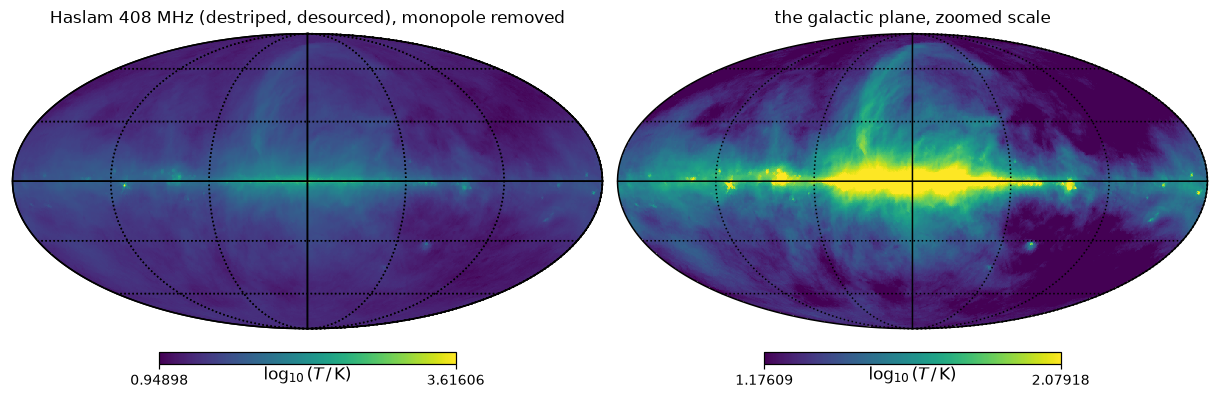

In [2]:
sky_gain = products["sky_gain"]

fig = plt.figure(figsize=(11, 4))
hp.mollview(np.log10(sky_gain), title="Haslam 408 MHz (destriped, desourced), "
            "monopole removed", unit=r"$\log_{10}(T\,/\,\mathrm{K})$",
            sub=(1, 2, 1), hold=False, notext=True)
hp.graticule(dpar=30, dmer=60)
hp.mollview(np.log10(sky_gain), title="the galactic plane, zoomed scale",
            unit=r"$\log_{10}(T\,/\,\mathrm{K})$", min=np.log10(15),
            max=np.log10(120), sub=(1, 2, 2), hold=False, notext=True)
hp.graticule(dpar=30, dmer=60)

print(f"{'':22}{'min':>10}{'median':>10}{'max':>10}")
print(f"{'sky_gain [K]':22}{sky_gain.min():10.2f}{np.median(sky_gain):10.2f}"
      f"{sky_gain.max():10.1f}")
print(f"\nstrictly positive everywhere: {bool(np.all(sky_gain > 0))}")
print("  (covA is inverted per pixel by the sampler, so a zero or a negative here")
print("   would blow up the amplitude solve rather than fail loudly)")

---
## 2. The region operators

`operator` maps 12 gain parameters onto pixels; `operator_spect` maps 6 spectral-index
regions. Both are 0/1 indicator matrices of galactic latitude bands, built exactly the way
`bayesian_skymap`'s own generator builds them (`tests/make_test_data.region_operator`) —
the test suite pins ours against theirs.

**The counts are 12 and 6, not 6 and 6.** The config previously claimed 6 gain regions
"matches the six regions bayesian_skymap initialises", but those six are the *spectral
index* regions (`BETA_REGIONS`); its generator uses `ngain = 12`. The gain is meant to have
more freedom than beta.

operator       (196608, 12)   rows sum to 1: True
operator_spect (196608, 6)   rows sum to 1: True

gain region pixel counts: [ 3280 10004 15276 20336 24064 25088 25600 23552 20848 15276 10004  3280]
beta region pixel counts: [13284 35612 49152 49152 36124 13284]


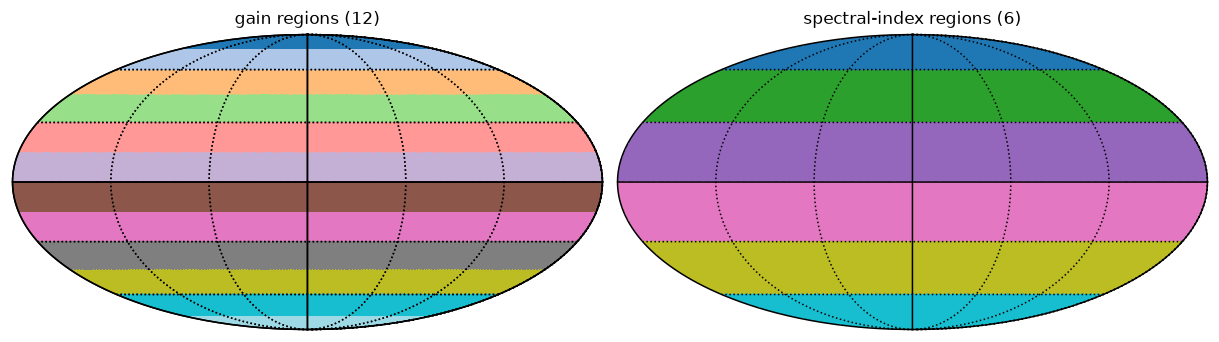

In [3]:
operator = products["operator"]
operator_spect = products["operator_spect"]

fig = plt.figure(figsize=(11, 4))
hp.mollview(products["gain_region_index"].astype(float),
            title=f"gain regions ({operator.shape[1]})", cmap="tab20",
            sub=(1, 2, 1), hold=False, notext=True, cbar=False)
hp.graticule(dpar=30, dmer=60)
hp.mollview(products["beta_region_index"].astype(float),
            title=f"spectral-index regions ({operator_spect.shape[1]})", cmap="tab10",
            sub=(1, 2, 2), hold=False, notext=True, cbar=False)
hp.graticule(dpar=30, dmer=60)

print(f"operator       {operator.shape}   rows sum to 1: "
      f"{bool(np.allclose(operator.sum(axis=1), 1))}")
print(f"operator_spect {operator_spect.shape}   rows sum to 1: "
      f"{bool(np.allclose(operator_spect.sum(axis=1), 1))}")
print(f"\ngain region pixel counts: {products['gain_region_pixels']}")
print(f"beta region pixel counts: {products['beta_region_pixels']}")

in force: haslam.region_geometry = theta_bands
theta_bands is bayesian_skymap's own convention, so it is the default here;
equal_area is available in the config if the polar imbalance becomes a problem.


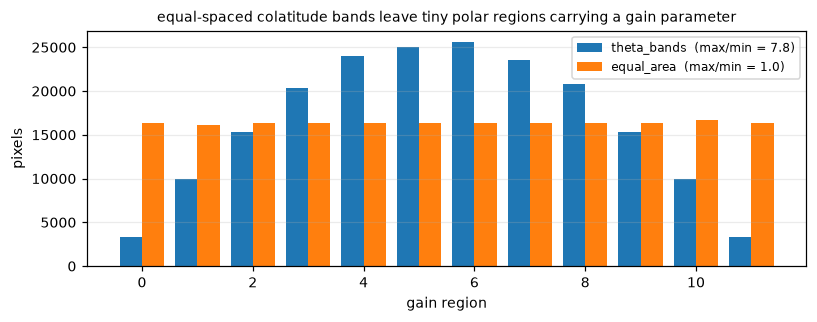

In [4]:
# The reason haslam.region_geometry = "equal_area" exists as an alternative.
fig, ax = plt.subplots(figsize=(7.5, 3.0))
width = 0.4
for offset, geometry, colour in ((-width/2, "theta_bands", "tab:blue"),
                                 (+width/2, "equal_area", "tab:orange")):
    counts = stage2.region_operator(NSIDE, operator.shape[1], geometry).sum(axis=0)
    ax.bar(np.arange(counts.size) + offset, counts, width, color=colour,
           label=f"{geometry}  (max/min = {counts.max()/counts.min():.1f})")
ax.set_xlabel("gain region"); ax.set_ylabel("pixels"); ax.legend(fontsize=8)
ax.grid(alpha=0.25, axis="y")
ax.set_title("equal-spaced colatitude bands leave tiny polar regions carrying a "
             "gain parameter", fontsize=9)
fig.tight_layout()

print(f"in force: haslam.region_geometry = {manifest['regions']['geometry']}")
print("theta_bands is bayesian_skymap's own convention, so it is the default here;")
print("equal_area is available in the config if the polar imbalance becomes a problem.")

---
## 3. Why the default prior is circular

The pipeline document wants Berkhuijsen (1972) at 820 MHz precisely because it is
**independent of Haslam**. It is not available offline, so the shipped default is GSM2008
evaluated at 408 MHz.

That is not a neutral substitute, and this is the cell that shows why: de Oliveira-Costa
et al. (2008) built GSM2008 by fitting a small set of principal components to eleven input
surveys — **one of which is the Haslam 408 MHz map**. Its output at 408 MHz is therefore a
smoothed reconstruction of Haslam, not an independent measurement of the same sky. If the
ratio below is flat, the "prior" is Haslam wearing a different name, and a gain recovered
against it cannot be evidence that Haslam's calibration is wrong.

Pearson r of log10(GSM2008 @ 408 MHz) against log10(Haslam): 0.993466
ratio GSM2008 / Haslam : median 1.0047, 16-84% [0.9735, 1.0479], scatter 0.1802
pixels within 5% of the median ratio: 79.9%


Text(0.5, 1.0, 'a near-constant scale factor, not an independent measurement')

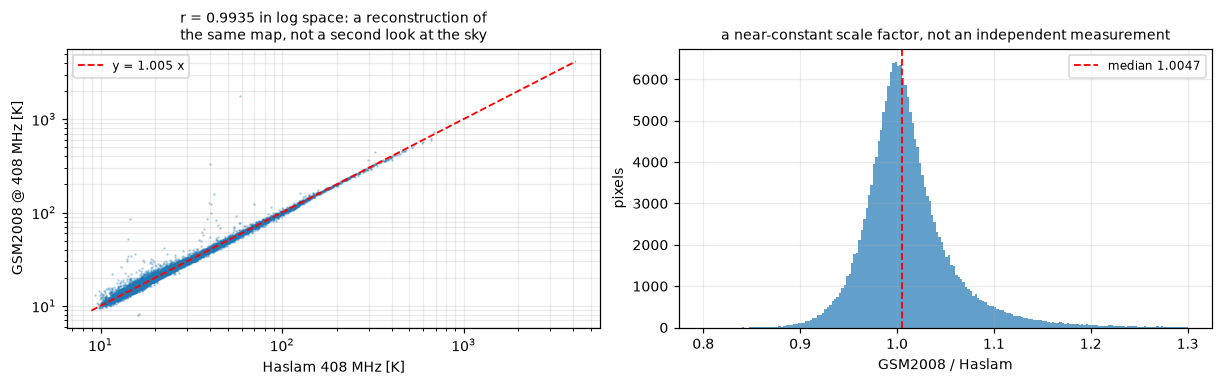

In [5]:
from pygdsm import GlobalSkyModel

gsm408 = hp.ud_grade(GlobalSkyModel().generate(408.0), NSIDE)
ratio = gsm408 / sky_gain
correlation = np.corrcoef(np.log10(gsm408), np.log10(sky_gain))[0, 1]

print(f"Pearson r of log10(GSM2008 @ 408 MHz) against log10(Haslam): {correlation:.6f}")
print(f"ratio GSM2008 / Haslam : median {np.median(ratio):.4f}, "
      f"16-84% [{np.percentile(ratio, 16):.4f}, {np.percentile(ratio, 84):.4f}], "
      f"scatter {ratio.std():.4f}")
print(f"pixels within 5% of the median ratio: "
      f"{100*np.mean(np.abs(ratio/np.median(ratio) - 1) < 0.05):.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), constrained_layout=True)
ax = axes[0]
sub = np.random.default_rng(0).choice(NPIX, 20000, replace=False)
ax.loglog(sky_gain[sub], gsm408[sub], ".", ms=1.5, alpha=0.25, color="tab:blue")
edge = np.array([sky_gain.min(), sky_gain.max()])
ax.loglog(edge, edge * np.median(ratio), "r--", lw=1.2,
          label=f"y = {np.median(ratio):.3f} x")
ax.set_xlabel("Haslam 408 MHz [K]"); ax.set_ylabel("GSM2008 @ 408 MHz [K]")
ax.legend(fontsize=8); ax.grid(alpha=0.25, which="both")
ax.set_title(f"r = {correlation:.4f} in log space: a reconstruction of\n"
             "the same map, not a second look at the sky", fontsize=9)

ax = axes[1]
ax.hist(ratio, bins=200, range=(0.8, 1.3), color="tab:blue", alpha=0.7)
ax.axvline(np.median(ratio), color="r", ls="--", lw=1.2,
           label=f"median {np.median(ratio):.4f}")
ax.set_xlabel("GSM2008 / Haslam"); ax.set_ylabel("pixels")
ax.legend(fontsize=8); ax.grid(alpha=0.25)
ax.set_title("a near-constant scale factor, not an independent measurement", fontsize=9)

In [6]:
print("This is why stage 2 records the flag rather than burying it:\n")
print(f"  prior_is_haslam_derived : {manifest['prior_is_haslam_derived']}")
print(f"  blocker_2_status        : {manifest['blocker_2_status']}\n")
print("Read literally: with this prior, stage 5's comparison of a recovered gain")
print("against the ~3% / ~0.91 K literature benchmark tests the plumbing, not the sky.")

This is why stage 2 records the flag rather than burying it:

  prior_is_haslam_derived : True
  blocker_2_status        : UNRESOLVED. The prior source is 'gsm2008'. GSM2008 is built from a set of surveys that includes Haslam 408 MHz, and at 408 MHz its reconstruction is dominated by it (log-space r = 0.993, median ratio 1.005), so this prior is NOT Haslam-independent. A gain recovered against it is circular. Berkhuijsen (1972) is the real answer.

Read literally: with this prior, stage 5's comparison of a recovered gain
against the ~3% / ~0.91 K literature benchmark tests the plumbing, not the sky.


---
## 4. The prior that is actually independent

`haslam.prior.source = tris_stage1` uses stage 1's TRIS maps, extrapolated from 600 MHz to
408 MHz. TRIS **is** an absolute radiometer, so this is genuinely Haslam-independent — but
only across the declination band it observed. Outside that band nothing independent
constrains anything, and the width falls back to something deliberately loose.

Note the frames: stage 1's maps are equatorial and everything here is galactic, so the band
is resampled by rotating each galactic pixel centre into equatorial and taking the stage 1
pixel it lands in — nearest neighbour, so nothing smears the band edge.

TRIS band covers 102824 of 196608 galactic pixels (52.3% of the sky)
prior sigma  in band: median    4.832 K
            out band: median  210.455 K (10x local sky, deliberately uninformative)

TRIS-extrapolated / Haslam, in band: median 1.027, 16-84% [0.982, 1.084]
That spread is a real cross-check between an absolute radiometer and Haslam,
which is exactly what the GSM2008 prior above cannot give you.


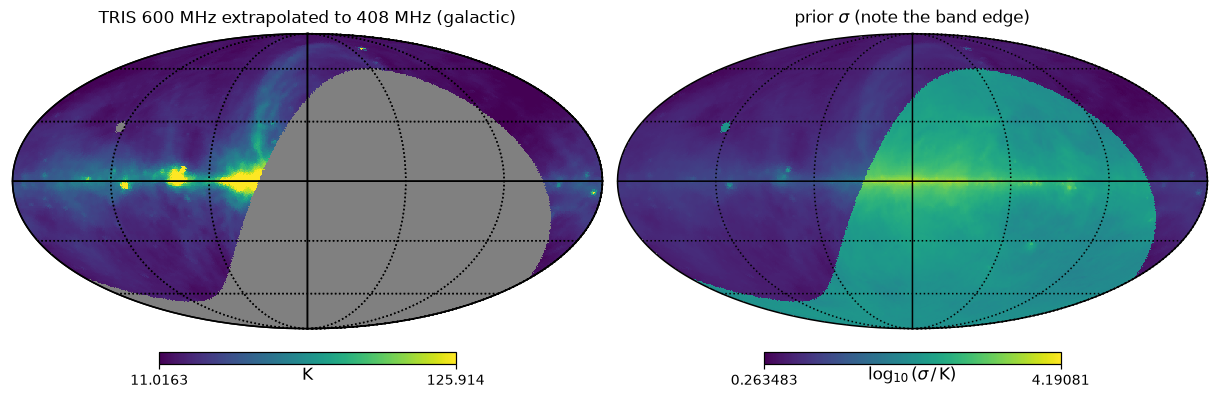

In [7]:
alt = load_config(REPO / "configs" / "run_config.yaml")
alt._data["haslam"]["prior"]["source"] = "tris_stage1"

try:
    tris_mean, tris_sigma, tris_meta = stage2.build_prior(alt, sky_gain)
    covered = tris_meta.pop("_covered")
    have_tris = True
except FileNotFoundError as error:
    have_tris = False
    print("stage 1 has not been run for this run name:", error)

if have_tris:
    print(f"TRIS band covers {covered.sum()} of {NPIX} galactic pixels "
          f"({covered.mean():.1%} of the sky)")
    print(f"prior sigma  in band: median {np.median(tris_sigma[covered]):8.3f} K")
    print(f"            out band: median {np.median(tris_sigma[~covered]):8.3f} K "
          f"({alt.get_path('haslam.prior.out_of_band_frac_sigma'):g}x local sky, "
          f"deliberately uninformative)")

    # How well does an absolutely-calibrated extrapolation agree with Haslam?
    scale = tris_mean[covered] / sky_gain[covered]
    print(f"\nTRIS-extrapolated / Haslam, in band: median {np.median(scale):.3f}, "
          f"16-84% [{np.percentile(scale, 16):.3f}, {np.percentile(scale, 84):.3f}]")
    print("That spread is a real cross-check between an absolute radiometer and Haslam,")
    print("which is exactly what the GSM2008 prior above cannot give you.")

    fig = plt.figure(figsize=(11, 4))
    hp.mollview(np.where(covered, tris_mean, np.nan),
                title="TRIS 600 MHz extrapolated to 408 MHz (galactic)", unit="K",
                min=np.percentile(tris_mean[covered], 1),
                max=np.percentile(tris_mean[covered], 99),
                sub=(1, 2, 1), hold=False, notext=True)
    hp.graticule(dpar=30, dmer=60)
    hp.mollview(np.log10(tris_sigma), title=r"prior $\sigma$ (note the band edge)",
                unit=r"$\log_{10}(\sigma\,/\,\mathrm{K})$",
                sub=(1, 2, 2), hold=False, notext=True)
    hp.graticule(dpar=30, dmer=60)

gibbs_*.py sets sprior_mean = 0 and only ever reads covA, so the template sets
the prior's SCALE, not its centre. The mean is emitted anyway in case stage 4
wires it in, but covA is the operative product.


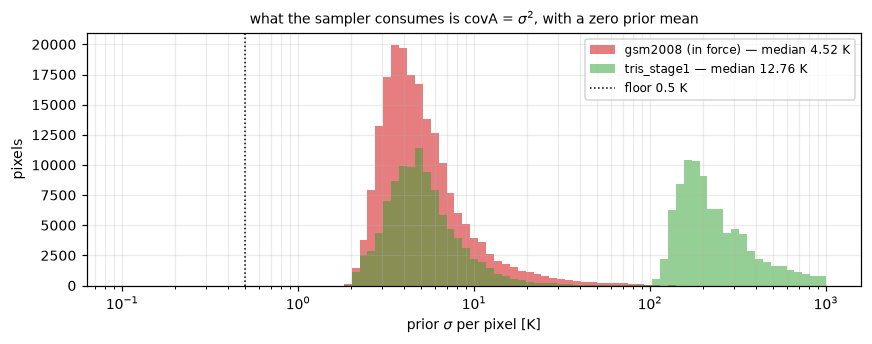

In [8]:
# The two priors side by side, as the sampler sees them: covA, a variance.
fig, ax = plt.subplots(figsize=(8, 3.2))
bins = np.logspace(-1, 3, 90)
ax.hist(products["prior_sigma_k"], bins=bins, alpha=0.6, color="tab:red",
        label=f"gsm2008 (in force) — median {np.median(products['prior_sigma_k']):.2f} K")
if have_tris:
    ax.hist(tris_sigma, bins=bins, alpha=0.5, color="tab:green",
            label=f"tris_stage1 — median {np.median(tris_sigma):.2f} K")
ax.axvline(alt.get_path("haslam.prior.floor_k"), color="k", ls=":", lw=1,
           label=f"floor {alt.get_path('haslam.prior.floor_k')} K")
ax.set_xscale("log"); ax.set_xlabel(r"prior $\sigma$ per pixel [K]")
ax.set_ylabel("pixels"); ax.legend(fontsize=8); ax.grid(alpha=0.25, which="both")
ax.set_title(r"what the sampler consumes is covA = $\sigma^2$, with a zero prior mean",
             fontsize=9)
fig.tight_layout()

print("gibbs_*.py sets sprior_mean = 0 and only ever reads covA, so the template sets")
print("the prior's SCALE, not its centre. The mean is emitted anyway in case stage 4")
print("wires it in, but covA is the operative product.")

---
## 5. What stage 3 will find here

`bayesian_skymap`'s `gibbs_spectral_nside.py` reads a fixed set of keys out of one `.npz`.
The table below is what stage 2 has supplied and what is still owed — stage 3's job is
assembly, not invention.

In [9]:
OWED = {
    "sky_gain":       ("stage 2", "Haslam, monopole removed"),
    "operator":       ("stage 2", "gain parameter -> pixel"),
    "operator_spect": ("stage 2", "beta region -> pixel"),
    "beta":           ("stage 2", "beta_init_map, from assemble.beta_init"),
    "sky_haslam":     ("stage 2", "s0_init_k -- the Blocker 2 truth substitute"),
    "sky_lowres":     ("stage 3", "stage 1 TRIS maps, rotated to galactic"),
    "pixel_mask":     ("stage 3", "the rotated TRIS footprint at nside_new"),
    "freq":           ("stage 3", "TRIS frequencies + 408 MHz last"),
    "ref_freq":       ("stage 3", "tris.ref_freq_mhz"),
    "freq_beam":      ("stage 3", "assemble.freq_beam_mhz"),
    "lmax_beam":      ("stage 3", "assemble.lmax_beam"),
    "gain":           ("NOBODY",  "the TRUE gain -- does not exist for real data"),
}
have = {"sky_gain": "sky_gain", "operator": "operator",
        "operator_spect": "operator_spect", "beta": "beta_init_map",
        "sky_haslam": "s0_init_k"}

print(f"{'npz key':16}{'owner':9}{'shape here':>18}   note")
for key, (owner, note) in OWED.items():
    local = have.get(key)
    shape = str(products[local].shape) if local else "-"
    print(f"{key:16}{owner:9}{shape:>18}   {note}")

print(f"\ncovG substitute: {products['covG_diag'][:3]} ... "
      f"({products['covG_diag'].size} regions)")
print(f"  {manifest['gain_prior']['note']}")

npz key         owner            shape here   note
sky_gain        stage 2           (196608,)   Haslam, monopole removed
operator        stage 2        (196608, 12)   gain parameter -> pixel
operator_spect  stage 2         (196608, 6)   beta region -> pixel
beta            stage 2           (196608,)   beta_init_map, from assemble.beta_init
sky_haslam      stage 2           (196608,)   s0_init_k -- the Blocker 2 truth substitute
sky_lowres      stage 3                   -   stage 1 TRIS maps, rotated to galactic
pixel_mask      stage 3                   -   the rotated TRIS footprint at nside_new
freq            stage 3                   -   TRIS frequencies + 408 MHz last
ref_freq        stage 3                   -   tris.ref_freq_mhz
freq_beam       stage 3                   -   assemble.freq_beam_mhz
lmax_beam       stage 3                   -   assemble.lmax_beam
gain            NOBODY                    -   the TRUE gain -- does not exist for real data

covG substitute: [0.0225 0

---
## Verdict

* **The Haslam side is ready.** The map is on `bayesian_skymap`'s grid, in galactic
  coordinates, monopole removed, strictly positive. The region operators are byte-identical
  to what that repository builds for itself.
* **Two truth-informed quantities have substitutes, and both are recorded.** `covG` is
  built in `gibbs_*.py` from the *true* gain; stage 2 emits the same width evaluated at
  `g = 0`. `sky_haslam` is read as the true sky; stage 2 emits `s0_init_k` instead. Neither
  is a truth and the manifest says so.
* **Blocker 2 is not resolved.** Section 3 is the measurement: with `prior.source =
  gsm2008` the prior tracks Haslam at r = 0.993 in log space with a median ratio of 1.005,
  so it carries no information Haslam does not already carry. Stages 3–5
  can be exercised end to end on it, and the numbers that come out will look plausible —
  which is exactly the danger the flag exists for.

**What changes when Berkhuijsen arrives.** One config line:

```yaml
paths:
  berkhuijsen_map: data/berkhuijsen_820mhz.fits
haslam:
  prior:
    source: berkhuijsen_1972
```

Stage 2 then extrapolates 820 → 408 MHz with `extrapolation_beta`, sets
`prior_is_haslam_derived: false`, and nothing else in the pipeline has to change.
`tris_stage1` is the honest interim: independent where TRIS looked, loose everywhere else.